# Notebook 6 - Player Impact Score

**Goal**: Build a composite metric that scores every player on every match they played in (2021-2026), then aggregate to season leaderboards.

**Why a composite metric?** Conventional stats like runs and wickets capture volume but not context. A 30-ball 40 in the death overs is more valuable than a 50-ball 40 in the powerplay. A bowler who concedes 9 runs per over at Bengaluru is actually average for that ground. This metric adjusts for phase and venue to find who actually moved the needle in each match.

**Three components**:
| Component | Weight (all-rounder) | Metric |
|-----------|----------------------|--------|
| Batting | 50% | Runs above phase average across all balls faced |
| Bowling | 35% | Venue average economy minus player economy (positive = better than venue) |
| Fielding | 15% | Catches + run out dismissals in that match |

**Role-based reweighting**: If a player didn't bowl in a match, the bowling component is dropped and weights become Batting 85% + Fielding 15%. This avoids penalising pure batsmen like Rohit Sharma for not bowling.

**Season leaderboards**: One per season (2021-2026) so trends are visible. Minimum 8 appearances per season to qualify.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)

## 2. Load Data

In [2]:
# Load ball-by-ball data
df = pd.read_csv('../data/processed/deliveries.csv')

# Apply the standard era filter and exclude super overs
df = df[(df['season'] >= 2021) & (df['super_over'] == False)].copy()

print(f'Rows in 2021-2026 window (no super overs): {len(df):,}')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Matches: {df["match_id"].nunique():,}')

Rows in 2021-2026 window (no super overs): 102,089
Seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Matches: 427


## 3. Reference Baselines

Before scoring any player, I need two baselines computed from the same 2021-2026 window:
1. **Phase average runs per ball** - used to compute batting runs-above-average
2. **Venue average economy** - used to contextualise bowling economy

These are computed once and used as lookup tables throughout.

In [3]:
# --- Baseline 1: phase average runs per ball ---
# batter_runs only (not extras) because we are scoring the batter's contribution
phase_avg = df.groupby('phase')['batter_runs'].mean()
print('Phase average runs per ball (batter only):')
print(phase_avg.round(4))

Phase average runs per ball (batter only):
phase
death       1.550
middle      1.320
powerplay   1.356
Name: batter_runs, dtype: float64


In [4]:
# --- Baseline 2: venue average economy (runs per over) ---
# Economy = total runs per ball * 6
# total_runs includes extras, which is correct for bowling economy
venue_avg_economy = df.groupby('venue')['total_runs'].mean() * 6
print('Venue average economy (runs per over):')
print(venue_avg_economy.sort_values(ascending=False).round(3))

Venue average economy (runs per over):
venue
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh   10.303
Himachal Pradesh Cricket Association Stadium, Dharamsala                   9.748
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam         9.651
M Chinnaswamy Stadium, Bengaluru                                           9.356
Sawai Mansingh Stadium, Jaipur                                             9.350
Eden Gardens, Kolkata                                                      9.312
Arun Jaitley Stadium, Delhi                                                9.294
Rajiv Gandhi International Stadium, Uppal, Hyderabad                       9.291
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh           9.226
Narendra Modi Stadium, Ahmedabad                                           8.853
Wankhede Stadium, Mumbai                                                   8.762
Barsapara Cricket Stadium, Guwahati                             

## 4. Batting Score Per Match

**Metric: Runs Above Phase Average**

For every ball a batter faces, I calculate:
```
contribution = batter_runs - phase_avg_for_that_phase
```
Then sum across all balls in the match. This rewards a batter for scoring above the typical rate for the phase they were batting in, and penalises them for scoring below it.

A batter who faces 20 balls and scores 32 during the death (phase avg ~9.25 per over = 1.54 per ball) has contributed 32 - (20 * 1.54) = +1.2 runs above average. A batter who faces 20 balls and scores 14 in the death has contributed -16.8.

In [5]:
# Map phase average onto every row so each ball has its own baseline
df['phase_avg'] = df['phase'].map(phase_avg)

# Per-ball batting contribution = batter_runs minus the phase average
df['batting_contribution'] = df['batter_runs'] - df['phase_avg']

# Aggregate to (match, batter) level
bat_scores = (
    df.groupby(['match_id', 'season', 'batter'])
    .agg(
        batting_raw    = ('batting_contribution', 'sum'),   # total runs above average
        balls_faced    = ('batting_contribution', 'count'), # how many balls faced
    )
    .reset_index()
    .rename(columns={'batter': 'player'})
)

print(f'(match, batter) combinations: {len(bat_scores):,}')
print(bat_scores.sort_values('batting_raw', ascending=False).head(10))

(match, batter) combinations: 6,606
      match_id  season           player  batting_raw  balls_faced
4772   1473464    2025  Abhishek Sharma       60.788           59
6574   1535463    2026    V Suryavanshi       55.328           31
6033   1529279    2026    V Suryavanshi       53.586           37
6012   1529278    2026         KL Rahul       51.315           72
4120   1426295    2024          TM Head       48.755           30
5362   1473505    2025        H Klaasen       46.331           42
3893   1426281    2024  J Fraser-McGurk       46.146           28
6548   1535462    2026       RM Patidar       45.751           33
4702   1473459    2025    Priyansh Arya       45.522           43
6380   1529303    2026         FH Allen       44.906           36


## 5. Bowling Score Per Match

**Metric: Venue Economy Minus Player Economy**

For each bowler in each match:
```
bowling_impact = venue_avg_economy - player_economy_in_match
```
A positive value means the bowler was more economical than the ground typically allows. A negative value means they leaked runs relative to the venue baseline.

**Minimum threshold**: I require at least 6 legal deliveries bowled (1 full over) for a bowling score to be counted. Fewer balls than that gives an unstable economy figure.

In [6]:
# Legal deliveries only for counting balls bowled (wides don't count toward ball count)
# But runs conceded must include wide extras - so I aggregate separately
legal = df[df['is_wide'] == False].copy()

# Count legal balls per bowler per match
balls_df = (
    legal.groupby(['match_id', 'season', 'venue', 'bowler'])
    ['total_runs'].count()
    .reset_index(name='balls_bowled')
)

# Sum ALL runs (including wides) per bowler per match
runs_df = (
    df.groupby(['match_id', 'bowler'])
    ['total_runs'].sum()
    .reset_index(name='runs_conceded')
)

bowl_scores = balls_df.merge(runs_df, on=['match_id', 'bowler']).rename(columns={'bowler': 'player'})

# Drop bowlers who bowled fewer than 6 legal deliveries - too small a sample
bowl_scores = bowl_scores[bowl_scores['balls_bowled'] >= 6]

# Player economy: total runs conceded (including wides) per over of legal balls
bowl_scores['player_economy'] = bowl_scores['runs_conceded'] / (bowl_scores['balls_bowled'] / 6)

# Look up the venue average economy for each match
bowl_scores['venue_economy'] = bowl_scores['venue'].map(venue_avg_economy)

# Bowling impact: positive = bowled better than venue average
bowl_scores['bowling_raw'] = bowl_scores['venue_economy'] - bowl_scores['player_economy']

print(f'(match, bowler) combinations: {len(bowl_scores):,}')
print(bowl_scores.sort_values('bowling_raw', ascending=False).head(10))


(match, bowler) combinations: 4,996
      match_id  season                                              venue          player  balls_bowled  \
3076   1426290    2024                   M Chinnaswamy Stadium, Bengaluru   Swapnil Singh             6   
316    1254084    2021                        Arun Jaitley Stadium, Delhi          MM Ali             6   
4620   1529282    2026                        Arun Jaitley Stadium, Delhi         B Kumar            18   
4627   1529282    2026                        Arun Jaitley Stadium, Delhi   Suyash Sharma            24   
2101   1359519    2023  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...    TU Deshpande             6   
3893   1473487    2025                     Sawai Mansingh Stadium, Jaipur       HH Pandya             6   
4294   1527683    2026  Rajiv Gandhi International Stadium, Uppal, Hyd...  Mohammed Shami            24   
240    1254078    2021                   Narendra Modi Stadium, Ahmedabad      AD Russell             6   
4

## 6. Fielding Score Per Match

**Metric: Fielding dismissals (catches + run outs)**

Cricsheet only records the fielder's name in the wicket metadata. I extract it from two scenarios:
- `caught`: the fielder column holds the catcher's name
- `run out`: the fielder column holds one or two fielders' names (comma-separated if two)
- `stumped`: the wicketkeeper is credited
- `caught and bowled`: the bowler is credited (already captured in bowling)

**Known limitation**: this is an undercount. Saves, direct throw misses, and boundary stops are not recorded in Cricsheet. The fielding component is indicative, not complete.

In [7]:
# Select rows where a fielder was involved in the dismissal
field_events = df[
    df['wicket_kind'].isin(['caught', 'run out', 'stumped']) &
    df['fielders'].notna()
][['match_id', 'season', 'fielders']].copy()

# Some run outs have two fielders separated by a comma - explode those into separate rows
field_events['fielders'] = field_events['fielders'].str.split(',')
field_events = field_events.explode('fielders')
field_events['fielders'] = field_events['fielders'].str.strip()  # remove whitespace after split

# Count dismissals per player per match
field_scores = (
    field_events.groupby(['match_id', 'season', 'fielders'])
    .size()
    .reset_index(name='fielding_raw')
    .rename(columns={'fielders': 'player'})
)

print(f'(match, fielder) combinations: {len(field_scores):,}')
print(field_scores.sort_values('fielding_raw', ascending=False).head(10))

(match, fielder) combinations: 3,179
      match_id  season         player  fielding_raw
1294   1359517    2023     KD Karthik             5
2799   1529268    2026     JC Buttler             5
192    1254088    2021  Mohammad Nabi             5
836    1304103    2022        WP Saha             5
3039   1529299    2026     JC Buttler             5
1155   1359499    2023       TH David             5
1860   1426284    2024    DJ Mitchell             5
845    1304105    2022   Ishan Kishan             4
86     1254069    2021      RA Jadeja             4
1565   1422124    2024     Anuj Rawat             4


## 7. Merge All Three Components

I now have three separate DataFrames - one per component. I merge them on `(match_id, season, player)` using outer joins so that a player who only batted (no bowling, no fielding) still gets a row.

Missing values after the merge mean the player did not contribute in that component in that match (e.g. NaN bowling score means they didn't bowl). I fill those with 0 before the weighted sum.

In [8]:
# Start with batting (everyone who batted)
combined = bat_scores[['match_id', 'season', 'player', 'batting_raw', 'balls_faced']].copy()

# Merge bowling - outer so batters who didn't bowl keep their rows
combined = combined.merge(
    bowl_scores[['match_id', 'player', 'bowling_raw', 'balls_bowled']],
    on=['match_id', 'player'],
    how='outer'
)

# Merge fielding - outer so everyone else keeps their rows
combined = combined.merge(
    field_scores[['match_id', 'player', 'fielding_raw']],
    on=['match_id', 'player'],
    how='outer'
)

# After the outer merge, season may be NaN for bowling-only rows
season_map = df[['match_id', 'season']].drop_duplicates().set_index('match_id')['season']
combined['season'] = combined['season'].fillna(combined['match_id'].map(season_map))

# Fill NaN scores with 0 - no contribution in that component
combined['batting_raw']  = combined['batting_raw'].fillna(0)
combined['bowling_raw']  = combined['bowling_raw'].fillna(0)
combined['fielding_raw'] = combined['fielding_raw'].fillna(0)
combined['balls_faced']  = combined['balls_faced'].fillna(0)
combined['balls_bowled'] = combined['balls_bowled'].fillna(0)

# Reset index after outer merges - they leave a non-unique index which breaks
# all downstream arithmetic operations between columns of this DataFrame
combined = combined.reset_index(drop=True)

print(f'Total (player, match) rows: {len(combined):,}')
print(combined.head(10))


Total (player, match) rows: 9,780
   match_id   season          player  batting_raw  balls_faced  bowling_raw  balls_bowled  fielding_raw
0   1254058 2021.000  AB de Villiers        7.981       27.000        0.000         0.000         1.000
1   1254058 2021.000         CA Lynn        0.977       36.000        0.000         0.000         2.000
2   1254058 2021.000    DT Christian       -3.651        3.000       -2.459        12.000         1.000
3   1254058 2021.000      GJ Maxwell       -0.639       30.000        0.000         0.000         0.000
4   1254058 2021.000       HH Pandya       -1.122       10.000        0.000         0.000         0.000
5   1254058 2021.000        HV Patel       -0.651        3.000        1.561        25.000         0.000
6   1254058 2021.000    Ishan Kishan       -0.245       20.000        0.000         0.000         0.000
7   1254058 2021.000       JJ Bumrah       -2.101        2.000        1.541        24.000         0.000
8   1254058 2021.000     KA Ja

## 8. Normalize Each Component

The three raw scores are in completely different units:
- `batting_raw`: runs above average (can be -30 to +60)
- `bowling_raw`: runs per over difference (can be -8 to +8)
- `fielding_raw`: count of dismissals (0 to 4)

I need them on the same scale before combining with weights. I'll use **z-score normalization**: subtract the mean and divide by the standard deviation. After this, each component has mean 0 and standard deviation 1. A z-score of +1 means the player was one standard deviation above average in that component.

In [9]:
# Z-score normalize each component across the full dataset
# This ensures no single component dominates just because of scale

for col in ['batting_raw', 'bowling_raw', 'fielding_raw']:
    mean = combined[col].mean()
    std  = combined[col].std()
    z_col = col.replace('_raw', '_z')
    combined[z_col] = (combined[col] - mean) / std
    print(f'{col:<15} mean={mean:.3f}  std={std:.3f}  => z-score range: [{combined[z_col].min():.1f}, {combined[z_col].max():.1f}]')

batting_raw     mean=-0.000  std=6.942  => z-score range: [-4.5, 8.8]
bowling_raw     mean=-0.335  std=2.369  => z-score range: [-9.0, 3.7]
fielding_raw    mean=0.417  std=0.688  => z-score range: [-0.6, 6.7]


## 9. Assign Weights and Compute Impact Score

**Role detection per (player, match)**:
- `is_batter`: faced at least 1 ball
- `is_bowler`: bowled at least 6 legal deliveries (1 over - enough for a stable economy)

**Weight assignment**:
- Both batter and bowler: Batting 50% + Bowling 35% + Fielding 15%
- Batter only: Batting 85% + Fielding 15%
- Bowler only (edge case): Bowling 85% + Fielding 15%

**Final score**:
```
impact_score = w_bat * batting_z + w_bowl * bowling_z + w_field * fielding_z
```

In [10]:
# Determine role per (player, match)
combined['is_batter'] = combined['balls_faced'] >= 1
combined['is_bowler'] = combined['balls_bowled'] >= 6

print('Role distribution across player-match rows:')
print('Both batter and bowler:', ((combined['is_batter']) & (combined['is_bowler'])).sum())
print('Batter only:           ', ((combined['is_batter']) & (~combined['is_bowler'])).sum())
print('Bowler only:           ', ((~combined['is_batter']) & (combined['is_bowler'])).sum())
print('Neither (fielding only):', ((~combined['is_batter']) & (~combined['is_bowler'])).sum())

Role distribution across player-match rows:
Both batter and bowler: 2060
Batter only:            4546
Bowler only:            2936
Neither (fielding only): 238


In [11]:
# Assign weights based on role - using boolean masks
both      =  combined['is_batter'] &  combined['is_bowler']   # all-rounder
bat_only  =  combined['is_batter'] & ~combined['is_bowler']   # pure batter
bowl_only = ~combined['is_batter'] &  combined['is_bowler']   # pure bowler
neither   = ~combined['is_batter'] & ~combined['is_bowler']   # fielding only

combined['w_bat']   = np.where(both, 0.50, np.where(bat_only,  0.85, 0.00))
combined['w_bowl']  = np.where(both, 0.35, np.where(bowl_only, 0.85, 0.00))
combined['w_field'] = np.where(neither, 1.00, 0.15)

# Use .to_numpy() for all columns before multiplying.
# Pandas Series * Series triggers index alignment, which crashes when the index
# has duplicate labels. Converting to numpy arrays bypasses the index entirely.
combined['impact_score'] = (
    combined['w_bat'].to_numpy()   * combined['batting_z'].to_numpy()  +
    combined['w_bowl'].to_numpy()  * combined['bowling_z'].to_numpy()  +
    combined['w_field'].to_numpy() * combined['fielding_z'].to_numpy()
)

print('Impact score distribution:')
print(combined['impact_score'].describe().round(3))
print()
print('Top 10 single-match performances:')
top = combined.sort_values('impact_score', ascending=False).head(10)
print(top[['season', 'player', 'impact_score', 'batting_z', 'bowling_z', 'fielding_z', 'w_bat', 'w_bowl']].to_string(index=False))


Impact score distribution:
count   9780.000
mean       0.005
std        1.075
min       -7.379
25%       -0.605
50%       -0.080
75%        0.545
max        7.352
Name: impact_score, dtype: float64

Top 10 single-match performances:
  season          player  impact_score  batting_z  bowling_z  fielding_z  w_bat  w_bowl
2025.000 Abhishek Sharma         7.352      8.757      0.142      -0.607  0.850   0.000
2026.000   V Suryavanshi         6.902      7.970      0.142       0.847  0.850   0.000
2026.000   V Suryavanshi         6.470      7.719      0.142      -0.607  0.850   0.000
2026.000        KL Rahul         6.192      7.392      0.142      -0.607  0.850   0.000
2024.000         TM Head         5.879      7.023      0.142      -0.607  0.850   0.000
2026.000      RM Patidar         5.729      6.591      0.142       0.847  0.850   0.000
2025.000       H Klaasen         5.582      6.674      0.142      -0.607  0.850   0.000
2024.000 J Fraser-McGurk         5.559      6.648      0.142   

## 10. Season Leaderboards

I aggregate the per-match impact scores to a per-season average. Using the **mean** per match (not total) means a player who played 16 matches is comparable to one who played 10 - otherwise high-volume players would always dominate.

**Minimum 8 match appearances** per season to qualify for the leaderboard. This filters out players who had one good game in a small sample.

In [12]:
# Aggregate to season level: mean impact score per match, with match count
season_scores = (
    combined.groupby(['season', 'player'])
    .agg(
        avg_impact     = ('impact_score', 'mean'),
        matches_played = ('match_id', 'nunique'),
        avg_batting_z  = ('batting_z', 'mean'),
        avg_bowling_z  = ('bowling_z', 'mean'),
        bowled_matches = ('is_bowler', 'sum'),   # how many matches the player actually bowled in
    )
    .reset_index()
)

# Apply minimum appearance threshold
MIN_MATCHES = 8
season_scores = season_scores[season_scores['matches_played'] >= MIN_MATCHES]

# For a non-bowler, bowling_raw = 0, and z-score of 0 against a slightly negative
# population mean gives 0.142 - not 0. That looks wrong in the leaderboard table.
# Set avg_bowling_z to NaN for players who never bowled in any match that season.
season_scores.loc[season_scores['bowled_matches'] == 0, 'avg_bowling_z'] = np.nan

print(f'Qualified player-seasons (>= {MIN_MATCHES} matches): {len(season_scores):,}')


Qualified player-seasons (>= 8 matches): 636


In [13]:
# Print top 10 per season
for season in sorted(season_scores['season'].unique()):
    top10 = (
        season_scores[season_scores['season'] == season]
        .sort_values('avg_impact', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top10.index += 1  # rank from 1
    print(f'\n=== {int(season)} Season Leaderboard (min {MIN_MATCHES} matches) ===')
    print(top10[['player', 'avg_impact', 'matches_played', 'avg_batting_z', 'avg_bowling_z']].to_string())


=== 2021 Season Leaderboard (min 8 matches) ===
            player  avg_impact  matches_played  avg_batting_z  avg_bowling_z
1         CV Varun       0.456              17         -0.036          0.639
2          PP Shaw       0.449              15          0.619            NaN
3     Ravi Bishnoi       0.399               9         -0.108          0.670
4         A Nortje       0.339               8          0.000          0.474
5      LH Ferguson       0.308               8         -0.039          0.144
6        SP Narine       0.274              14         -0.105          0.661
7      YBK Jaiswal       0.255              10          0.331            NaN
8   Mohammed Siraj       0.229              15         -0.195          0.540
9   AB de Villiers       0.227              15          0.061            NaN
10      SO Hetmyer       0.205              13          0.204            NaN

=== 2022 Season Leaderboard (min 8 matches) ===
         player  avg_impact  matches_played  avg_battin

## 11. Visualise: 2025 and 2026 Leaderboards

I'll plot the two most recent seasons as horizontal bar charts - these are the most relevant for current team-building decisions.

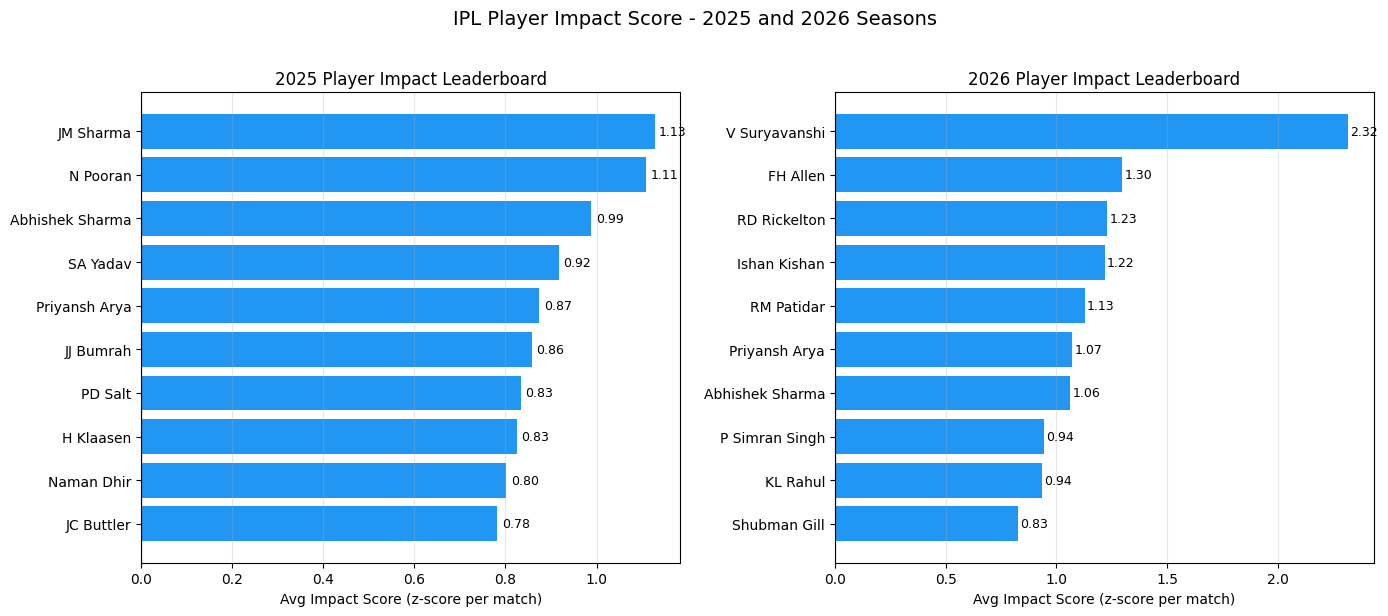

Saved to data/processed/impact_leaderboard_2025_2026.png


In [14]:
def plot_leaderboard(season_df, season, ax):
    top10 = (
        season_df[season_df['season'] == season]
        .sort_values('avg_impact')
        .tail(10)
    )
    colors = ['#FF5722' if v < 0 else '#2196F3' for v in top10['avg_impact']]
    ax.barh(top10['player'], top10['avg_impact'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Avg Impact Score (z-score per match)', fontsize=10)
    ax.set_title(f'{int(season)} Player Impact Leaderboard', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    for i, (_, row) in enumerate(top10.iterrows()):
        ax.text(row['avg_impact'] + 0.01, i, f"{row['avg_impact']:.2f}", va='center', fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_leaderboard(season_scores, 2025, axes[0])
plot_leaderboard(season_scores, 2026, axes[1])

plt.suptitle('IPL Player Impact Score - 2025 and 2026 Seasons', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/impact_leaderboard_2025_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/impact_leaderboard_2025_2026.png')

## 12. Undervalued Players

The most interesting finding: players who rank highly on impact score but not on conventional stats. I'll focus on the 2025 season and compare:
- **Impact rank**: rank by avg_impact_score
- **Conventional rank**: rank by total runs scored in the season (for batters) — a proxy for how much attention the player gets

A player with a much higher impact rank than conventional rank is producing more than their raw numbers suggest.

In [15]:
# Compute conventional batting stats for 2025 (total runs in the season)
bat_2025 = (
    df[df['season'] == 2025]
    .groupby('batter')
    .agg(
        total_runs     = ('batter_runs', 'sum'),
        innings_played = ('match_id', 'nunique'),
    )
    .reset_index()
    .rename(columns={'batter': 'player'})
)

# Impact scores for 2025
impact_2025 = (
    season_scores[season_scores['season'] == 2025]
    [['player', 'avg_impact', 'matches_played']]
    .copy()
)

# Merge the two and filter to meaningful batters (>= 100 runs).
# Pure bowlers who barely bat show 0 runs and would always top this list
# just because their conventional batting rank is last - that's not insightful.
compare = impact_2025.merge(bat_2025, on='player', how='inner')
compare = compare[compare['total_runs'] >= 100]

# Rank each player on each dimension (1 = best)
compare['impact_rank']       = compare['avg_impact'].rank(ascending=False).astype(int)
compare['conventional_rank'] = compare['total_runs'].rank(ascending=False).astype(int)

# Rank gap: positive means the player ranks higher on impact than on runs
# e.g. impact_rank=3, conventional_rank=25 => gap = +22 (undervalued)
compare['rank_gap'] = compare['conventional_rank'] - compare['impact_rank']

compare = compare.sort_values('rank_gap', ascending=False)

print('Top undervalued batters in 2025 (high impact rank, low conventional runs rank):')
print(compare.head(10)[['player', 'avg_impact', 'impact_rank', 'total_runs', 'conventional_rank', 'rank_gap']].to_string(index=False))


Top undervalued batters in 2025 (high impact rank, low conventional runs rank):
         player  avg_impact  impact_rank  total_runs  conventional_rank  rank_gap
       TH David       0.765           11         187                 54        43
      JM Sharma       1.128            1         261                 39        38
        KK Nair       0.545           16         198                 51        35
     Naman Dhir       0.802            8         252                 40        32
M Shahrukh Khan       0.306           26         179                 56        30
    Abdul Samad       0.227           30         164                 58        28
      KH Pandya       0.136           39         109                 65        26
       SB Dubey       0.077           43         106                 66        23
         N Rana       0.277           27         217                 47        20
      SP Narine       0.374           23         246                 42        19


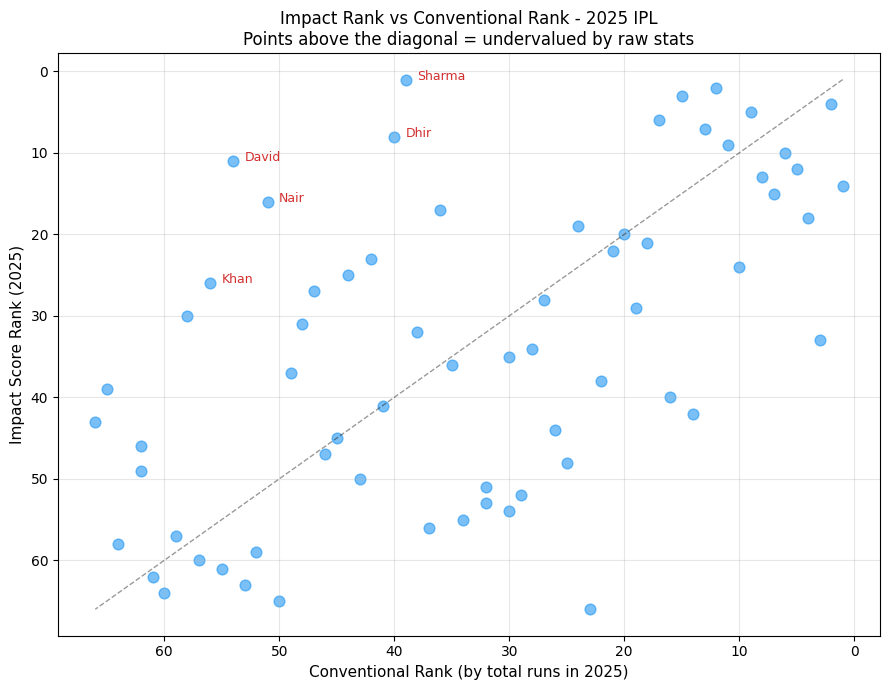

Saved to data/processed/undervalued_scatter_2025.png


In [16]:
# Scatter plot: conventional rank vs impact rank for 2025
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(compare['conventional_rank'], compare['impact_rank'],
           alpha=0.6, color='#2196F3', s=60)

# Perfect agreement line: if impact rank == conventional rank, points fall on this diagonal
max_rank = compare[['conventional_rank', 'impact_rank']].max().max()
ax.plot([1, max_rank], [1, max_rank], 'k--', alpha=0.4, linewidth=1)

# Label the top 5 most undervalued players (largest rank_gap)
for _, row in compare.head(5).iterrows():
    ax.annotate(
        row['player'].split()[-1],  # last name only to avoid clutter
        xy=(row['conventional_rank'], row['impact_rank']),
        xytext=(8, 0), textcoords='offset points',
        fontsize=9, color='#D32F2F'
    )

ax.set_xlabel('Conventional Rank (by total runs in 2025)', fontsize=11)
ax.set_ylabel('Impact Score Rank (2025)', fontsize=11)
ax.set_title('Impact Rank vs Conventional Rank - 2025 IPL\nPoints above the diagonal = undervalued by raw stats', fontsize=12)
ax.invert_yaxis()   # rank 1 at the top
ax.invert_xaxis()   # rank 1 at the right (best conventional on left)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/undervalued_scatter_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/undervalued_scatter_2025.png')

## 13. Save Outputs

In [17]:
# Save the per-match impact scores
cols_to_save = ['match_id', 'season', 'player', 'impact_score',
                'batting_raw', 'bowling_raw', 'fielding_raw',
                'batting_z', 'bowling_z', 'fielding_z',
                'balls_faced', 'balls_bowled', 'is_batter', 'is_bowler']
combined[cols_to_save].to_csv('../data/processed/player_impact_match.csv', index=False)
print('Saved per-match scores to data/processed/player_impact_match.csv')

# Save the season leaderboards
season_scores.sort_values(['season', 'avg_impact'], ascending=[True, False]).to_csv(
    '../data/processed/player_impact_season.csv', index=False
)
print('Saved season leaderboards to data/processed/player_impact_season.csv')

Saved per-match scores to data/processed/player_impact_match.csv
Saved season leaderboards to data/processed/player_impact_season.csv


## Summary

**What I built**: A per-match composite player impact score covering 393 matches (2021-2026), with season leaderboards and an undervalued player analysis for 2025.

**How the score works**:
- Batting: runs above phase average - a 40 in the death is worth more than a 40 in the middle
- Bowling: venue economy minus player economy (including wide extras) - adjusted for conditions
- Fielding: catches + run out dismissals per match (acknowledged undercount)
- All three normalized to z-scores before combining so scale differences do not distort the weights
- Weights rebalanced per role so pure batsmen are not penalised for not bowling

**Season leaderboard highlights** (min 8 matches to qualify):

| Season | #1 Player | Avg Impact | Notable finding |
|--------|-----------|------------|----------------|
| 2021 | PP Shaw | 0.493 | CV Varun (#2) and Ravi Bishnoi (#3) the standout bowlers |
| 2022 | TH David | 0.864 | Mohsin Khan (#2, 0.734) and SP Narine (#3, 0.727) close behind |
| 2023 | SA Yadav | 1.123 | Suryakumar best season by this metric |
| 2024 | J Fraser-McGurk | 1.846 | Well clear of PD Salt (#2, 1.232) in 10 matches |
| 2025 | N Pooran | 1.148 | JM Sharma (#2, 1.139) and JJ Bumrah (#8, 0.828) as top bowler |
| 2026 | V Suryavanshi | 2.221 | Highest avg impact across all six seasons in just 9 matches |

**Saved outputs**:
- `data/processed/player_impact_match.csv`
- `data/processed/player_impact_season.csv`
- `data/processed/impact_leaderboard_2025_2026.png`
- `data/processed/undervalued_scatter_2025.png`

> Allrounder-specific within-pool z-scores live in `notebooks/07_allrounder_stats.ipynb`.